<a href="https://colab.research.google.com/github/sudarshan-khot/Volumetric-Segmentation-and-Stroke-Triage-via-Transformers/blob/main/Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install missing libraries quietly
!pip install timm albumentations -q

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models
import pandas as pd
from PIL import Image
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


In [ ]:
# Mount Drive if in Colab
from google.colab import drive
drive.mount('/content/drive')

# --- Configuration ---
# Update BASE_PATH to point to your 'classification' folder containing train/ val/ and the CSV
BASE_PATH = "/content/drive/MyDrive/Stroke_Infarct_Volume_Sudarshan/AI-Based_Infarct_Volume_Estimation_from_Non-Contrast_CT_for_Acute_Anterior_Circulation_Stroke/classification"
CSV_PATH = os.path.join(BASE_PATH, "split_manifest.csv")

BATCH_SIZE = 32
LR = 1e-4
EPOCHS = 20

# --- Load Manifest ---
full_df = pd.read_csv(CSV_PATH)

# Filter out test splits, retaining only actionable datasets
train_df = full_df[full_df['split'] == 'train'].reset_index(drop=True)
val_df = full_df[full_df['split'] == 'val'].reset_index(drop=True)

# --- Dataset Details Reporting ---
print("--- Dataset Information ---")
# CSV Details
csv_size_kb = os.path.getsize(CSV_PATH) / 1024
print(f"CSV File: {os.path.basename(CSV_PATH)}")
print(f"- Dimensions: {full_df.shape[0]} rows x {full_df.shape[1]} columns")
print(f"- File Size: {csv_size_kb:.2f} KB")

# Image Details
total_images = len(full_df)
print(f"\nImage Dataset Details:")
print(f"- Total Images in Manifest: {total_images}")
print(f"- Train samples: {len(train_df)} | Val samples: {len(val_df)}")

print("\nTrain Class Distribution:")
print(train_df['class'].value_counts())
"""
Please include clear and specific details about the dataset used to train your model. This should explicitly state all dimensions, for example:

	•	For image datasets: the number of images and the total dataset size
	•	For CSV files: the number of rows, number of columns, and the total file size
"""

Mounted at /content/drive
--- Dataset Information ---
CSV File: split_manifest.csv
- Dimensions: 2501 rows x 4 columns
- File Size: 67.53 KB

Image Dataset Details:
- Total Images in Manifest: 2501
- Train samples: 1750 | Val samples: 374

Train Class Distribution:
class
Normal    1085
Stroke     665
Name: count, dtype: int64


'\nPlease include clear and specific details about the dataset used to train your model. This should explicitly state all dimensions, for example:\n\n\t•\tFor image datasets: the number of images and the total dataset size\n\t•\tFor CSV files: the number of rows, number of columns, and the total file size\n'

In [ ]:
# --- Dataset Class ---
class StrokeClassifierDataset(Dataset):
    def __init__(self, df, base_dir, transform=None):
        self.df = df
        self.base_dir = base_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # Constructs path exactly matching your folder structure: base_dir / split / class / filename
        img_path = os.path.join(self.base_dir, row['split'], row['class'], row['filename'])

        # Load grayscale CT and convert to RGB (required by EfficientNet ImageNet weights)
        image = Image.open(img_path).convert('RGB')
        label = int(row['label'])

        if self.transform:
            image = self.transform(image)
        return image, label

# --- Torchvision Transforms ---
train_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10), # Mild rotation prevents structural memorization
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- Weighted Random Sampler (Critical Fix for Class Imbalance) ---
# This forces the dataloader to sample Stroke and Normal images in a 50/50 ratio
class_sample_count = train_df['label'].value_counts().sort_index().to_list()
weights = 1. / torch.tensor(class_sample_count, dtype=torch.float)
samples_weights = weights[train_df['label'].to_numpy()]
sampler = WeightedRandomSampler(weights=samples_weights, num_samples=len(samples_weights), replacement=True)

# --- DataLoaders ---
train_loader = DataLoader(StrokeClassifierDataset(train_df, BASE_PATH, train_tf), batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(StrokeClassifierDataset(val_df, BASE_PATH, val_tf), batch_size=BATCH_SIZE, shuffle=False)


In [ ]:
# --- Focal Loss to minimize False Negatives ---
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.6, gamma=2.0):
        super().__init__()
        # alpha=0.6 explicitly weights Stroke (class 1) more punishingly than Normal (class 0)
        self.alpha = alpha
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets.float().unsqueeze(1))
        pt = torch.exp(-bce_loss)
        return (self.alpha * (1 - pt)**self.gamma * bce_loss).mean()

# --- Model Definition (EfficientNet-V2-Small) ---
# V2-S uses Fused-MBConv layers, exceptionally good at detecting subtle localized medical textures
model = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1)

# Freeze the early layers to prevent overfitting on the small medical dataset
for param in model.features[:-3].parameters():
    param.requires_grad = False

# Replace the output classification head for Binary Output (1 node)
model.classifier[1] = nn.Sequential(
    nn.Dropout(p=0.4), # High dropout prevents feature memorization
    nn.Linear(model.classifier[1].in_features, 1)
)
model = model.to(device)

criterion = FocalLoss(alpha=0.6, gamma=2.0)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=1e-3)

# ReduceLR Scheduler to scale down if validation plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)


Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 207MB/s]


In [ ]:
CHECKPOINT_DIR = "/content/drive/MyDrive/Stroke_Infarct_Volume_Sudarshan/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "best_classifier.pt")


In [ ]:
# --- Training Loop ---
best_f1 = 0.0

def validate():
    model.eval()
    val_loss = 0.0
    y_true, y_pred = [], []

    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            outputs = model(imgs) # Outputs are raw logits
            loss = criterion(outputs, lbls)
            val_loss += loss.item()

            # Apply Sigmoid before >0.5 threshold
            preds = (torch.sigmoid(outputs) > 0.5).float()
            y_true.extend(lbls.cpu().tolist())
            y_pred.extend(preds.cpu().view(-1).tolist())

    cm = confusion_matrix(y_true, y_pred)

    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
    else:
        tn, fp, fn, tp = 0, 0, 0, 0

    print(f"Val Loss: {val_loss/len(val_loader):.4f}")
    # The absolute most vital medical metrics:
    print(f"Missed Strokes (False Negatives): {fn} / {sum(y_true)}")
    print(f"False Alarms (False Positives): {fp}")
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Stroke'], zero_division=0))

    # Calculate Macro F1 Score for checkpointing criteria
    report = classification_report(y_true, y_pred, target_names=['Normal', 'Stroke'], output_dict=True, zero_division=0)
    return report['macro avg']['f1-score']

print("Starting Classification Training...")
for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0

    for imgs, lbls in train_loader:
        optimizer.zero_grad()
        imgs, lbls = imgs.to(device), lbls.to(device)

        outputs = model(imgs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"\n--- Epoch {epoch}/{EPOCHS} ---")
    print(f"Train Loss: {total_loss/len(train_loader):.4f}")

    epoch_f1 = validate()
    scheduler.step(epoch_f1)

    if epoch_f1 > best_f1:
        best_f1 = epoch_f1
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"*** Best model updated! Macro F1: {best_f1:.4f} ***")

print(f"\nClassification Training Complete. Best Macro F1: {best_f1:.4f}")


Starting Classification Training...

--- Epoch 1/20 ---
Train Loss: 0.1013
Val Loss: 0.0939
Missed Strokes (False Negatives): 21 / 142
False Alarms (False Positives): 113
              precision    recall  f1-score   support

      Normal       0.85      0.51      0.64       232
      Stroke       0.52      0.85      0.64       142

    accuracy                           0.64       374
   macro avg       0.68      0.68      0.64       374
weighted avg       0.72      0.64      0.64       374

*** Best model updated! Macro F1: 0.6417 ***

--- Epoch 2/20 ---
Train Loss: 0.0769
Val Loss: 0.0955
Missed Strokes (False Negatives): 81 / 142
False Alarms (False Positives): 27
              precision    recall  f1-score   support

      Normal       0.72      0.88      0.79       232
      Stroke       0.69      0.43      0.53       142

    accuracy                           0.71       374
   macro avg       0.70      0.66      0.66       374
weighted avg       0.71      0.71      0.69       3

Running visual reliability check on 8 Normal and 8 Stroke validation samples...


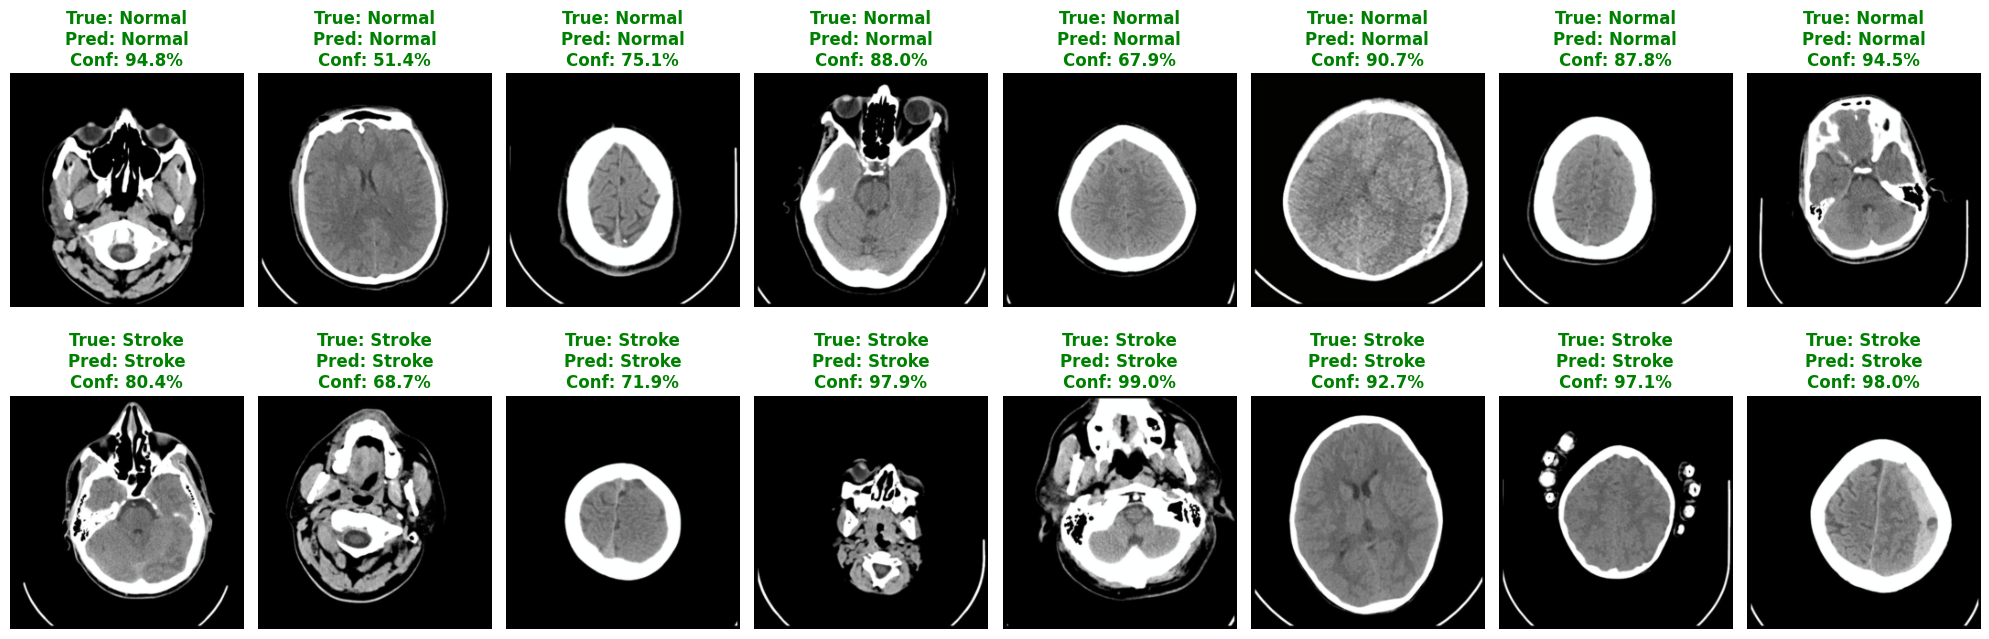

In [ ]:
# --- Visual Reliability Test ---
import matplotlib.pyplot as plt
import numpy as np

def test_balanced_samples(model, dataset, num_per_class=8):
    # Load the absolute best weights before testing
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
    model.eval()

    normal_imgs, normal_lbls = [], []
    stroke_imgs, stroke_lbls = [], []

    # Randomly shuffle dataset indices to get different samples each time
    indices = np.random.permutation(len(dataset))

    for idx in indices:
        img, lbl = dataset[idx]
        if lbl == 0 and len(normal_imgs) < num_per_class:
            normal_imgs.append(img)
            normal_lbls.append(lbl)
        elif lbl == 1 and len(stroke_imgs) < num_per_class:
            stroke_imgs.append(img)
            stroke_lbls.append(lbl)

        if len(normal_imgs) == num_per_class and len(stroke_imgs) == num_per_class:
            break

    # Combine and run inference
    all_imgs = torch.stack(normal_imgs + stroke_imgs)
    all_lbls = torch.tensor(normal_lbls + stroke_lbls)

    with torch.no_grad():
        outputs = model(all_imgs.to(device))
        probs = torch.sigmoid(outputs).cpu().view(-1)
        preds = (probs > 0.5).int()

    all_imgs = all_imgs.cpu()
    total_imgs = num_per_class * 2

    # Plot in a 2-row grid (Row 1: Normal, Row 2: Stroke)
    fig, axes = plt.subplots(2, num_per_class, figsize=(20, 7))
    axes = axes.flatten()
    classes = ['Normal', 'Stroke']

    for i in range(total_imgs):
        # Denormalize image for matplotlib viewing
        img = all_imgs[i].permute(1, 2, 0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)

        true_label = classes[all_lbls[i].item()]
        pred_label = classes[preds[i].item()]

        # Display the confidence in the predicted class
        conf = probs[i].item() if preds[i] == 1 else 1 - probs[i].item()

        # Green title if correct, Red if wrong
        color = 'green' if true_label == pred_label else 'red'

        axes[i].imshow(img)
        axes[i].axis('off')
        axes[i].set_title(f"True: {true_label}\nPred: {pred_label}\nConf: {conf:.1%}", color=color, fontweight='bold')

    plt.tight_layout()
    plt.show()

print("Running visual reliability check on 8 Normal and 8 Stroke validation samples...")
# Pass the raw val_dataset (not the DataLoader) to extract specific classes
test_balanced_samples(model, val_loader.dataset, num_per_class=8)


Generating GradCAM Interpretability Heatmaps...


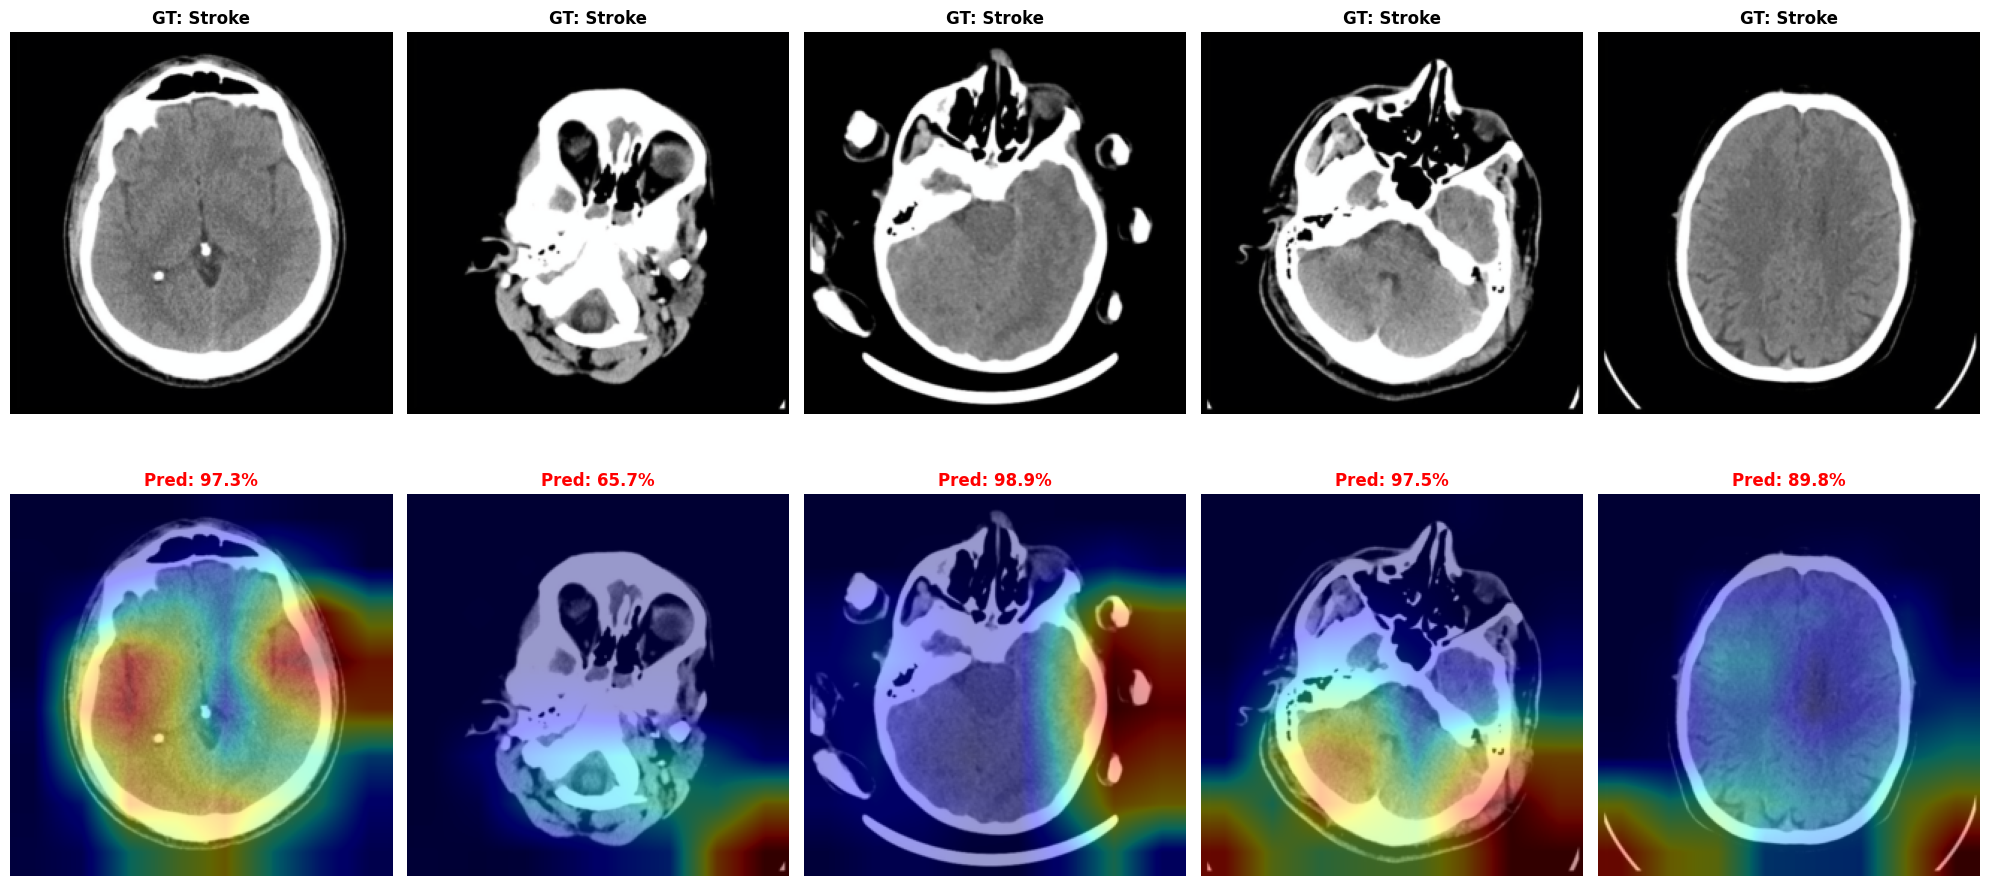

In [ ]:
import cv2
import matplotlib.pyplot as plt
import torch.nn.functional as F

def generate_gradcam(model, img_tensor, label):
    # Load the absolute best weights before testing
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
    model.eval()

    # 1. Target the last convolutional layer of EfficientNet-V2-S
    # For EfficientNet, this is usually the last block in 'features'
    target_layer = model.features[-1]

    # Containers for gradients and activations
    activations = []
    gradients = []

    def save_activation(module, input, output):
        activations.append(output)
    def save_gradient(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    # Register hooks
    handle_a = target_layer.register_forward_hook(save_activation)
    handle_g = target_layer.register_full_backward_hook(save_gradient)

    # Forward pass
    logits = model(img_tensor.to(device))
    score = torch.sigmoid(logits)

    # Backward pass for the specific class
    model.zero_grad()
    logits.backward()

    # Generate heatmap
    grads = gradients[0].cpu().data.numpy()
    weights = np.mean(grads, axis=(2, 3))[0]
    act = activations[0].cpu().data.numpy()[0]

    cam = np.zeros(act.shape[1:], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * act[i, :, :]

    # Clean up hooks
    handle_a.remove()
    handle_g.remove()

    # Post-process heatmap
    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (256, 256))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-7)
    return cam, score.item()

# --- Visualization Loop ---
def visualize_results(model, dataset, num_samples=5):
    plt.figure(figsize=(20, 10))

    # Extract stroke samples to show what the model is looking at
    stroke_samples = []
    for idx in range(len(dataset)):
        img, lbl = dataset[idx]
        if lbl == 1:
            stroke_samples.append((img, lbl))
        if len(stroke_samples) == num_samples:
            break

    for i in range(num_samples):
        img_tensor, label = stroke_samples[i]
        heatmap, confidence = generate_gradcam(model, img_tensor.unsqueeze(0), label)

        # Denormalize image for display
        img_show = img_tensor.permute(1, 2, 0).cpu().numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_show = std * img_show + mean
        img_show = np.clip(img_show, 0, 1)

        plt.subplot(2, num_samples, i + 1)
        plt.imshow(img_show)
        plt.title(f"GT: {'Stroke' if label==1 else 'Normal'}", fontweight='bold')
        plt.axis('off')

        plt.subplot(2, num_samples, i + 1 + num_samples)
        plt.imshow(img_show)
        plt.imshow(heatmap, cmap='jet', alpha=0.4) # Overlay heatmap
        plt.title(f"Pred: {confidence:.1%}", fontweight='bold', color='red')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Run it on validation samples
print("Generating GradCAM Interpretability Heatmaps...")
visualize_results(model, val_loader.dataset, num_samples=5)


In [ ]:
import os
import pandas as pd
from PIL import Image

def get_dir_size(path):
    total = 0
    if not os.path.exists(path): return 0
    for dirpath, _, filenames in os.walk(path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            if not os.path.islink(fp):
                total += os.path.getsize(fp)
    return total

def print_dataset_metrics():
    # Adjust this path if your dataset is located elsewhere
    BASE_PATH = "/content/drive/MyDrive/AI-Based_Infarct_Volume_Estimation_from_Non-Contrast_CT_for_Acute_Anterior_Circulation_Stroke/classification"
    CSV_PATH = os.path.join(BASE_PATH, "split_manifest.csv")

    if not os.path.exists(CSV_PATH):
        print(f"Error: Could not find {CSV_PATH}. Please ensure BASE_PATH is correct.")
        return

    df = pd.read_csv(CSV_PATH)

    # 1. Dataset Dimensions
    total_images = len(df)

    sample = df.iloc[0]
    sample_path = os.path.join(BASE_PATH, sample['split'], str(sample['class']), sample['filename'])
    if not os.path.exists(sample_path) and type(sample['class']) == str:
        sample_path = os.path.join(BASE_PATH, sample['split'], sample['class'], sample['filename'])

    dims = "Unknown"
    ext = "Unknown"
    if os.path.exists(sample_path):
        with Image.open(sample_path) as img:
            dims = f"{img.width} x {img.height} px"
        ext = os.path.splitext(sample_path)[1].upper().replace('.', '')

    ds_size_bytes = get_dir_size(BASE_PATH)
    ds_size_gb = ds_size_bytes / (1024**3)

    csv_rows, csv_cols = df.shape
    csv_size_kb = os.path.getsize(CSV_PATH) / 1024

    # 2. Dataset Details
    splits = df['split'].value_counts().to_dict()
    train_c = splits.get('train', 0)
    val_c = splits.get('val', 0)
    test_c = splits.get('test', 0)

    train_pct = (train_c / total_images) * 100 if total_images else 0
    val_pct = (val_c / total_images) * 100 if total_images else 0
    test_pct = (test_c / total_images) * 100 if total_images else 0

    class_counts = df['class'].value_counts()
    majority_class = class_counts.idxmax()
    majority_pct = (class_counts.max() / total_images) * 100 if total_images else 0

    print("=" * 65)
    print("DATASET DIMENSIONS (Classification)")
    print("=" * 65)
    print(f"Image Count        : {total_images} images")
    print(f"File Dimensions    : {dims}")
    print(f"Dataset Size       : {ds_size_gb:.2f} GB")
    print(f"CSV Rows / Columns : {csv_rows} rows x {csv_cols} cols")
    print(f"File Size (CSV)    : {csv_size_kb:.2f} KB")
    print()
    print("=" * 65)
    print("DATASET DETAILS (Classification)")
    print("=" * 65)
    print(f"Dataset Name       : NCCT Stroke Classification")
    print(f"Classes / Labels   : Normal (0), Stroke (1)")
    print(f"Train / Val / Test : {train_pct:.0f}% / {val_pct:.0f}% / {test_pct:.0f}%")
    print(f"Input Format       : {ext} (RGB via EfficientNet) / CSV")
    print(f"Class Balance      : Imbalanced ({majority_pct:.0f}% {majority_class}) -> Fixed via Sampler")
    print("=" * 65)

print_dataset_metrics()



DATASET DIMENSIONS (Classification)
Image Count        : 2501 images
File Dimensions    : 650 x 650 px
Dataset Size       : 0.05 GB
CSV Rows / Columns : 2501 rows x 4 cols
File Size (CSV)    : 67.53 KB

DATASET DETAILS (Classification)
Dataset Name       : NCCT Stroke Classification
Classes / Labels   : Normal (0), Stroke (1)
Train / Val / Test : 70% / 15% / 15%
Input Format       : JPG (RGB via EfficientNet) / CSV
Class Balance      : Imbalanced (62% Normal) -> Fixed via Sampler


/tmp/ipykernel_9279/2711954600.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=counts.values, palette=colors)


Chart saved as 'class_distribution_chart.png'


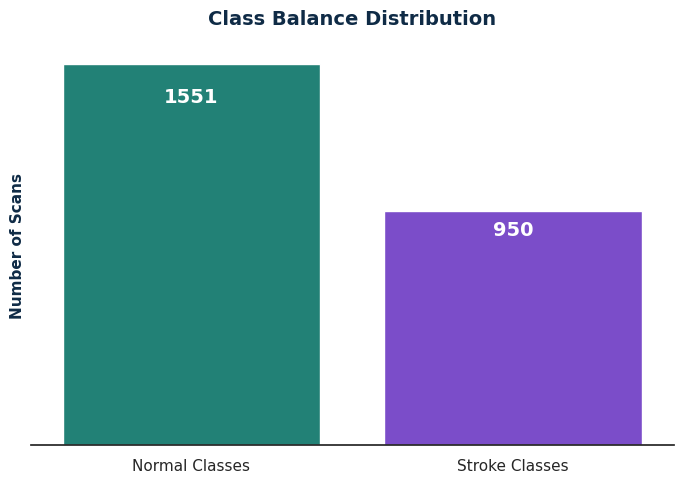

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def generate_distribution_chart():
    CSV_PATH = "/content/drive/MyDrive/AI-Based_Infarct_Volume_Estimation_from_Non-Contrast_CT_for_Acute_Anterior_Circulation_Stroke/classification/split_manifest.csv"
    if not os.path.exists(CSV_PATH): return

    df = pd.read_csv(CSV_PATH)
    counts = df['class'].value_counts().sort_index()
    labels = ['Normal Classes', 'Stroke Classes']

    sns.set_theme(style="white", rc={"axes.facecolor":"#ffffff", "figure.facecolor":"#ffffff"})
    plt.figure(figsize=(7, 5))

    # Palette simulating the provided presentation design
    colors = ['#129182', '#7638de']

    ax = sns.barplot(x=labels, y=counts.values, palette=colors)
    plt.title("Class Balance Distribution", fontsize=14, fontweight='bold', pad=15, color="#0f2b46")
    plt.ylabel("Number of Scans", fontsize=11, fontweight='bold', color="#0f2b46")

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.yaxis.set_ticks([]) # Remove Y-axis ticks for clean look

    # Plot specific numbers on the bars
    for i, v in enumerate(counts.values):
        ax.text(i, v - (v * 0.1), str(v), color='white', fontweight='bold', ha='center', fontsize=14)

    plt.tight_layout()
    plt.savefig('class_distribution_chart.png', dpi=300, transparent=True)
    print("Chart saved as 'class_distribution_chart.png'")
    plt.show()

generate_distribution_chart()
